## [Denoising Diffusion Probabilistic Models](https://arxiv.org/pdf/2006.11239)

### In this notebook, we are implementing Denoising Diffusion Probabilistic Models algorithm on Swiss Roll dataset.
<ol>
    <li>
        <b>Diffusion Model</b>
        <ol>
            <li>Forward Process:</li>
                <p>
                    Forward process or diffusion process is fixed to a Markov chain that gradually adds Gaussian noise to the data according to a variance schedule β₁, ..., βₜ:
                    $$
                        q(x_{1:T} \mid x_0) :=
                        \prod_{t=1}^{T} q(x_t \mid x_{t-1}),
                        \qquad
                        q(x_t \mid x_{t-1}) :=
                        \mathcal{N}
                        \left(
                            x_t;
                            \sqrt{1-\beta_t}\,x_{t-1},
                            \beta_t I
                            \right
                        )
                    $$
                </p>
            <li>Reverse Process</li>
                <p>
                    The joint distribution $p_θ (x_{0:T})$ is called the reverse process, and it is defined as a Markov chain with learned Gaussian transitions starting at $p(x_T ) = \mathcal{N} (x_T ; 0, I)$:
                    $$
                        p_{\theta}(x_{0:T}) :=
                        p(x_T) \prod_{t=1}^{T}
                        p_{\theta}(x_{t-1}\mid x_t),
                        \qquad
                        p_{\theta}(x_{t-1}\mid x_t)
                        :=
                        \mathcal{N}
                        \left(
                            x_{t-1};
                            \mu_{\theta}(x_t, t),
                            \Sigma_{\theta}(x_t, t)
                            \right)
                        $$
                </p>
        </ol>
    </li>
    <li> <b>Loss function:-</b>
        $$
            \mathbb{E}\left[-\log p_{\theta}(x_0)\right]
            \leq
            \mathbb{E}_{q}\left[
            -\log
            \frac{p_{\theta}(x_{0:T})}
            {q(x_{1:T}\mid x_0)}
            \right]
        $$
        $$
            =\mathbb{E}_{q}\left[-\log p(x_T)-
            \sum_{t\geq 1}
            \log
            \frac{p_{\theta}(x_{t-1}\mid x_t)}
            {q(x_t\mid x_{t-1})}
            \right]
            := \mathcal{L}
        $$
        Simplied loss which resembles denoising score matching over multiple noise scales indexed by t.
        $$
            \mathbb{E}_{x_0,\epsilon}
            \left[
            \frac{\beta_t^2}
            {2\sigma_t^2\alpha_t(1-\bar{\alpha}_t)}
            \|\,
            \epsilon -
            \epsilon_\theta
            \left(
            \sqrt{\bar{\alpha}_t}\,x_0 +
            \sqrt{1-\bar{\alpha}_t}\,\epsilon,
            t
            \right)
            \,\|^2
            \right]
        $$
    </li>
</ol>

In [151]:
import torch

from torch import nn

from dataclasses import dataclass
from torch.utils.data import Dataset, DataLoader

from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

import numpy as np

from tqdm import tqdm


import random
import matplotlib.pyplot as plt

In [152]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

#### Training Configuration Parameters

In [153]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 256
    num_epochs: int = 40
    learning_rate: float = 1e-3

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./data/"
    num_workers: int = 0 #number of thread involving in loading image
    deviec:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cpu


#### Generate the diffustion of Swiss Roll dataset

In [154]:
class DiffusionSwissRollDataset(Dataset):
    def __init__(self, length=100000, T = 100):
        self.length = length
        self.T = T
        self.beta_1 = 1e-4
        self.beta_T = 0.02
        self.beta = np.linspace(self.beta_1, self.beta_T, self.T)
        self.alpha = 1 - self.beta
        self.alpha_dash = self.calculate_alpha_dash() 

    def calculate_alpha_dash(self):
        alpha_dash = self.alpha.copy()
        cul_mul = 1
        for i in range(self.T):
            cul_mul *= self.alpha[i]
            alpha_dash[i] = cul_mul
        return alpha_dash
            
    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        time = 1.5 * torch.pi * (1 + 2 * torch.rand(1))

        x_0 = time * torch.cos(time)
        y_0 = time * torch.sin(time)

        t = torch.randint(1, self.T, (1,))

        eplision = torch.randn(2)
        
        x_t = (torch.sqrt(torch.tensor(self.alpha_dash[t])) * x_0) + (torch.sqrt(torch.tensor(1-self.alpha_dash[t])) * eplision[0]) 
        y_t = (torch.sqrt(torch.tensor(self.alpha_dash[t])) * y_0) + (torch.sqrt(torch.tensor(1-self.alpha_dash[t])) * eplision[1]) 
        
        point = torch.cat([x_0, y_0, t, x_t, y_t, eplision])

        return point

dataset = DiffusionSwissRollDataset(T=1000)

train_loader = DataLoader(
    dataset,
    batch_size=train_config.batch_size,
    shuffle=True
)

#### Visualize the data

Text(0.5, 1.0, 'Diffusion (T = 1000) Swiss Roll 2D')

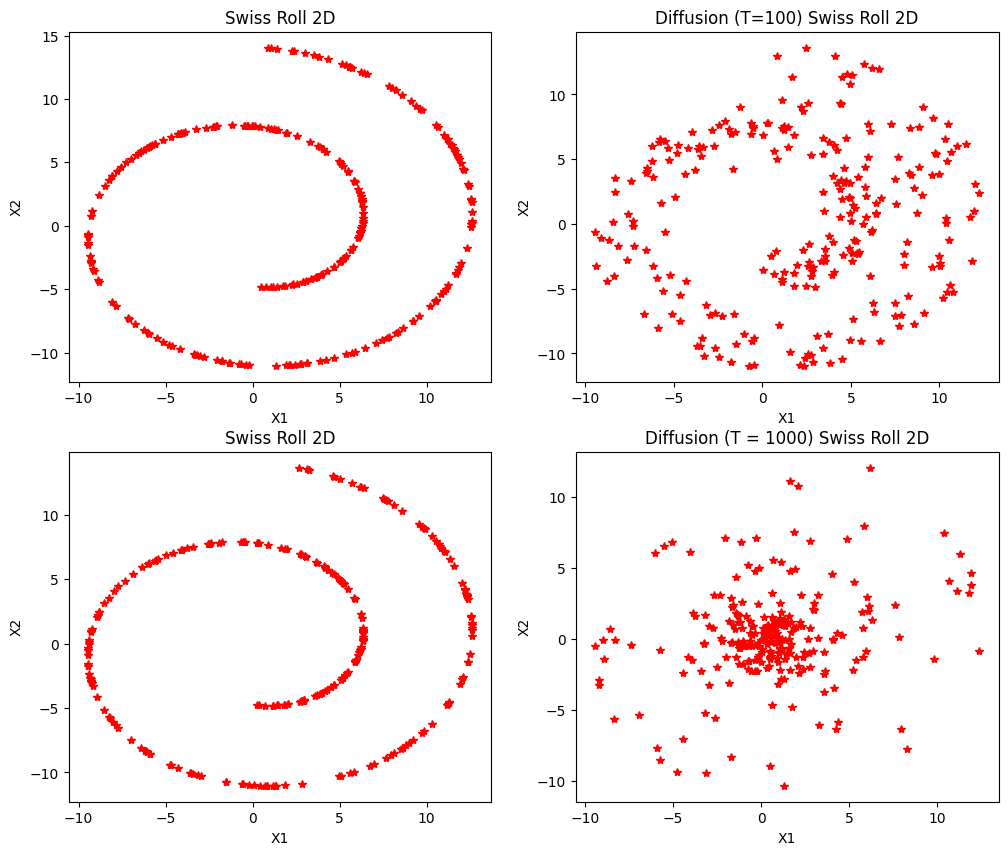

In [155]:
dataset1 = DiffusionSwissRollDataset(T=100)

train_loader1 = DataLoader(
    dataset1,
    batch_size=train_config.batch_size,
    shuffle=True
)

train_data = next(iter(train_loader1))

fig = plt.figure(figsize=(12,10))

plt.subplot(221)
plt.plot(train_data[:,0], train_data[:,1], 'r*')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title("Swiss Roll 2D")

plt.subplot(222)
plt.plot(train_data[:,3], train_data[:,4], 'r*')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title("Diffusion (T=100) Swiss Roll 2D")

dataset2 = DiffusionSwissRollDataset(T=1000)

train_loader2 = DataLoader(
    dataset2,
    batch_size=train_config.batch_size,
    shuffle=True
)

train_data = next(iter(train_loader2))

plt.subplot(223)
plt.plot(train_data[:,0], train_data[:,1], 'r*')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title("Swiss Roll 2D")

plt.subplot(224)
plt.plot(train_data[:,3], train_data[:,4], 'r*')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title("Diffusion (T = 1000) Swiss Roll 2D")


#### MLP model

In [170]:
class DDPM(nn.Module):
    def __init__(self, num_error = 2):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features= num_error + 1, out_features=64),
            nn.ReLU(inplace=True),
            nn.Linear(in_features = 64, out_features = 128),
            nn.ReLU(inplace=True),
            nn.Linear(in_features = 128, out_features = 256),
            nn.ReLU(inplace=True),
            nn.Linear(in_features = 256, out_features = 128),
            nn.ReLU(inplace=True),
            nn.Linear(in_features = 128, out_features = 64),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=64, out_features= num_error)
        )
    def forward(self, x):
        x = self.mlp(x)
        return x

In [171]:
model = DDPM()

model = model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate, weight_decay=.00001)

logdir = "runs/80epoch-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,3)

print(summary(model, dummy_input, row_settings=["var_names"], device=DEVICE))

Layer (type (var_name))                  Output Shape              Param #
DDPM (DDPM)                              [1, 2]                    --
├─Sequential (mlp)                       [1, 2]                    --
│    └─Linear (0)                        [1, 64]                   256
│    └─ReLU (1)                          [1, 64]                   --
│    └─Linear (2)                        [1, 128]                  8,320
│    └─ReLU (3)                          [1, 128]                  --
│    └─Linear (4)                        [1, 256]                  33,024
│    └─ReLU (5)                          [1, 256]                  --
│    └─Linear (6)                        [1, 128]                  32,896
│    └─ReLU (7)                          [1, 128]                  --
│    └─Linear (8)                        [1, 64]                   8,256
│    └─ReLU (9)                          [1, 64]                   --
│    └─Linear (10)                       [1, 2]                    130

In [178]:
optimizer = torch.optim.Adam(model.parameters(), lr= 0.1*train_config.learning_rate, weight_decay=.00001)

#### Model Training and Evaluation

In [175]:
def train(model, train_loader, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model = model.to(DEVICE)

    running_loss = 0

    criterion = nn.MSELoss()
    for data in tqdm(train_loader, desc="Training"):
        input_data = data[:,2:5]
        target_data = data[:,5:7]

        input_data, target_data = input_data.to(DEVICE), target_data.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(input_data)

        #Diffusion regression loss
        loss = criterion(outputs, target_data)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    return avg_loss

In [176]:
def main(model, trainloader, DEVICE='cuda'):
    train_losses = []
    train_accuracies = []

    best_train_loss = 10000
    best_weights = None

    for epoch in range(train_config.num_epochs):
        
        train_loss = train(model,trainloader, optimizer, DEVICE)
    
        train_losses.append(train_loss)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} ")

        writer.add_scalar('Loss/train', train_loss)

        if train_loss < best_train_loss:
            best_train_loss = train_loss
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "best_diffusion.pt")
            
    return train_losses

In [179]:
train_losses = main(model, train_loader, DEVICE)

Training: 100%|███████████████████████████████| 391/391 [01:15<00:00,  5.14it/s]


Epoch 1 - Train loss: 0.44130968742663296 
Saving the model... 


Training: 100%|███████████████████████████████| 391/391 [01:36<00:00,  4.07it/s]


Epoch 2 - Train loss: 0.4393349238826186 
Saving the model... 


Training: 100%|███████████████████████████████| 391/391 [01:35<00:00,  4.10it/s]


...

Epoch 10 - Train loss: 0.42893407556711866 


Training: 100%|███████████████████████████████| 391/391 [01:29<00:00,  4.38it/s]


Epoch 11 - Train loss: 0.42891086679895213 


Training:   8%|██▍                             | 30/391 [00:07<01:29,  4.05it/s]


KeyboardInterrupt: 

### Inference (Sampling)

In [211]:
alpha = torch.tensor(dataset.alpha, dtype=torch.float32)
alpha_bar = torch.tensor(dataset.alpha_dash, dtype=torch.float32)
beta = torch.tensor(dataset.beta, dtype=torch.float32)

model.eval()

output = []

with torch.no_grad():

    for i in range(256):

        xt = torch.randn(2)

        for t in range(dataset.T - 1, -1, -1):

            t_ = torch.tensor(t)

            if t > 0:
                z = torch.randn_like(xt)
            else:
                z = torch.zeros_like(xt)

            inp = torch.cat([t_.float().unsqueeze(0), xt])

            epsilon_est = model(inp)

            xt = (
                (1 / torch.sqrt(alpha[t]))
                * (
                    xt
                    - ((1 - alpha[t]) / torch.sqrt(1 - alpha_bar[t]))
                    * epsilon_est
                )
                + torch.sqrt(beta[t]) * z
            )

        x0 = xt
        output.append(x0)

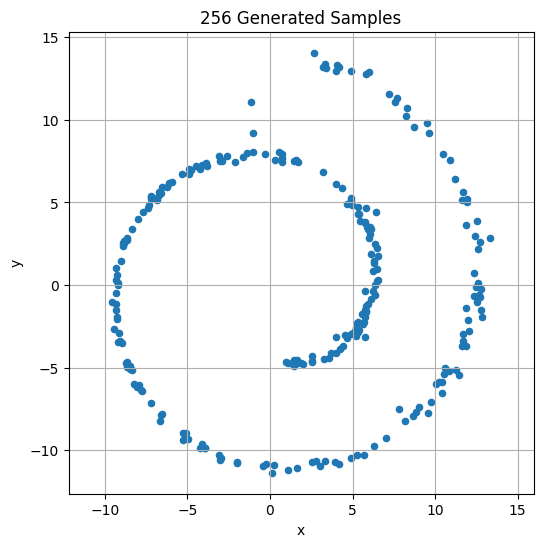

In [215]:
#samples = torch.tensor(output)

samples = np.array(output)

plt.figure(figsize=(6, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=20)
plt.title("256 Generated Samples")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.show()

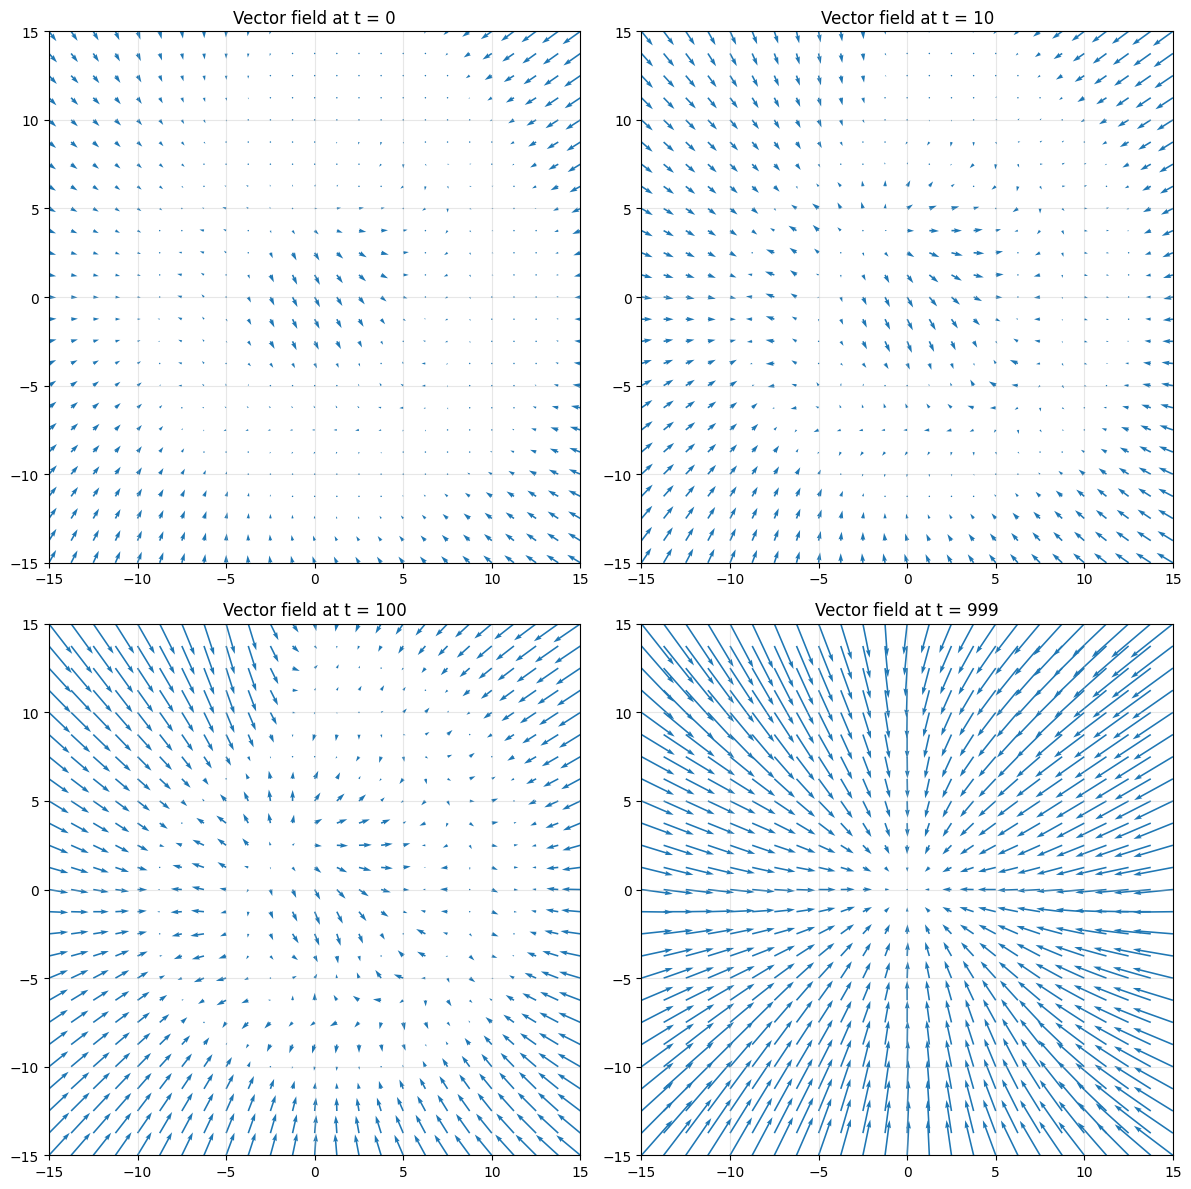

In [225]:
import torch
import matplotlib.pyplot as plt

model.eval()

alpha_bar = torch.tensor(dataset.alpha_dash, dtype=torch.float32)

# Timesteps to visualize
timesteps = [0, 10, 100, 999]

# Create meshgrid
x = torch.linspace(-15, 15, 25)
y = torch.linspace(-15, 15, 25)
X, Y = torch.meshgrid(x, y, indexing="xy")

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

with torch.no_grad():

    for ax, t in zip(axes, timesteps):

        U = torch.zeros_like(X)
        V = torch.zeros_like(Y)

        for i in range(X.shape[0]):
            for j in range(X.shape[1]):

                xt = torch.tensor([X[i, j], Y[i, j]])

                inp = torch.cat([
                    torch.tensor([float(t)]),
                    xt
                ])

                eps_pred = model(inp)

                U[i, j] = (-eps_pred[0]).item()
                V[i, j] = (-eps_pred[1]).item()

        ax.quiver(
            X.numpy(),
            Y.numpy(),
            U.numpy(),
            V.numpy(),
            angles="xy",
            scale_units="xy",
            scale=5,
            color="tab:blue",
            width=0.003
        )

        ax.set_title(f"Vector field at t = {t}")
        ax.set_xlim(-15, 15)
        ax.set_ylim(-15, 15)
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()